# 7.3) Aprendizagem baseada em instâncias -KNN - Base Census

In [1]:
import pickle
# read =rb 
with open('../2-3-Classificacao/census_aula.pkl', 'rb') as f:
  X_census_treinamento, y_census_treinamento, X_census_teste, y_census_teste = pickle.load(f)

In [2]:
X_census_treinamento.shape, y_census_treinamento.shape

((27676, 108), (27676,))

In [3]:
X_census_teste.shape, y_census_teste.shape

((4885, 108), (4885,))

In [5]:
# vizinhos e classificação
from sklearn.neighbors import KNeighborsClassifier

- padrão

##### pardrão de 5 vizinhos, e  o minkowski é o método de calcular a distância (the distance metric to use for the tree,

p= padrão de força sendo o 2 a distância euclidiana) .

class sklearn.neighbors.KNeighborsClassifier(n_neighbors=5, *, weights='uniform', algorithm='auto', leaf_size=30, p=2, metric='minkowski', metric_params=None, n_jobs=None)

https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html



#### metricstr or callable, default=’minkowski’

- Metric to use for distance computation. Default is “minkowski”, which results in the standard Euclidean distance when p = 2. See the documentation of scipy.spatial.distance and the metrics listed in distance_metrics for valid metric values.

If metric is “precomputed”, X is assumed to be a distance matrix and must be square during fit. X may be a sparse graph, in which case only “nonzero” elements may be considered neighbors.

If metric is a callable function, it takes two arrays representing 1D vectors as inputs and must return one value indicating the distance between those vectors. This works for Scipy’s metrics, but is less efficient than passing the metric name as a string.


- pfloat, default=2
- 
Power parameter for the Minkowski metric. When p = 1, this is equivalent to using manhattan_distance (l1), and euclidean_distance (l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used. This parameter is expected to be positive.

In [23]:
knn_census = KNeighborsClassifier(n_neighbors=10)
knn_census.fit(X_census_treinamento, y_census_treinamento) # fit para armazenar os dados

KNeighborsClassifier(n_neighbors=10)

In [24]:
# Mostrando os parâmetros
print(knn_census.get_params())

{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 10, 'p': 2, 'weights': 'uniform'}


In [25]:
# utilizando os vizinhos

previsoes = knn_census.predict(X_census_teste)
previsoes

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [26]:
previsoes[:30]

array([' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',
       ' >50K', ' <=50K', ' <=50K', ' <=50K', ' >50K', ' <=50K', ' <=50K',
       ' <=50K', ' <=50K', ' <=50K', ' >50K', ' <=50K', ' >50K', ' >50K',
       ' <=50K', ' <=50K', ' <=50K', ' <=50K'], dtype=object)

In [27]:
y_census_teste[:30]

array([' <=50K', ' <=50K', ' <=50K', ' <=50K', ' >50K', ' <=50K',
       ' <=50K', ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K', ' >50K',
       ' <=50K', ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50K', ' <=50K', ' >50K', ' >50K', ' <=50K', ' <=50K', ' >50K',
       ' <=50K', ' <=50K', ' <=50K', ' <=50K'], dtype=object)

In [28]:
y_census_teste

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

from sklearn.metrics import accuracy_score, classification_report
accuracy_score(y_census_teste, previsoes)

In [29]:
acuracia = accuracy_score(y_census_teste, previsoes)
print(f'Acurácia da instância KNN {acuracia*100:.2f} %') # o ideal é padronizar, tem que estar no mesmo valor de escala

Acurácia da instância KNN 82.91 %


In [32]:
# acurácia do modelo

# a acurácia, lembrando que no 2-Naive_Bayes_Bayesiano.ipynb, método bayesiano a acurácia era de apenas 47,68% no census
# a acurácia, lembrando que no 3-3_Arvore_decision_Census_parte4.ipynb, método da árvore de decisão simples a acurácia era de 81,04% no census
# a acurácia, lembrando que no 3-5_Arvore_decision_Random_Forest_Census.ipynb método das múltiplas árvores => A acurácia do modelo é de 85.08% para 100 árvores (n_estimators).
# a acurácia, lembrando que no 4-4_InducaodeRegras_BaseCEnsus.ipynb, método das regras => Acurácia do modelo 75.92 %

# Acurácia da instância KNN 82.23 % com 5 vizinhos próximos
# Acurácia da instância KNN 82.91 % ideal 10 vizinhos próximos

acurácia do modelo

- a acurácia, lembrando que no 2-Naive_Bayes_Bayesiano.ipynb, método bayesiano a acurácia era de apenas 47,68% no census

- a acurácia, lembrando que no 3-3_Arvore_decision_Census_parte4.ipynb, método da árvore de decisão simples a acurácia era de 81,04% no census

- a acurácia, lembrando que no 3-5_Arvore_decision_Random_Forest_Census.ipynb método das múltiplas árvores => A acurácia do modelo é de 85.08% para 100 árvores (n_estimators).

- a acurácia, lembrando que no 4-4_InducaodeRegras_BaseCEnsus.ipynb, método das regras => Acurácia do modelo 75.92 %



In [31]:
# maior quantidade de vizinhs, demora mais os processos | n_neighbors

Matriz da confusão

0.8290685772773797

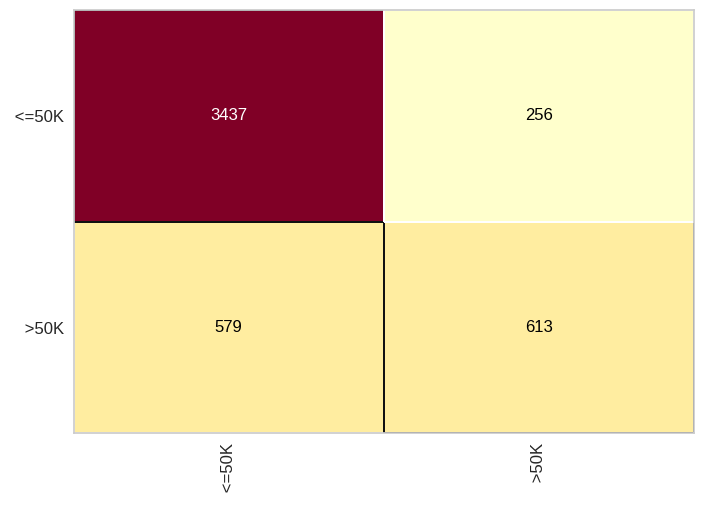

In [33]:
from yellowbrick.classifier import ConfusionMatrix
cm = ConfusionMatrix(knn_census)
cm.fit(X_census_treinamento, y_census_treinamento)
cm.score(X_census_teste, y_census_teste)


# <= 50K x <=50K 3437 ok


# > 50K x > 50K 613 ok


bom desempenho

In [34]:
print(classification_report(y_census_teste, previsoes))

              precision    recall  f1-score   support

       <=50K       0.86      0.93      0.89      3693
        >50K       0.71      0.51      0.59      1192

    accuracy                           0.83      4885
   macro avg       0.78      0.72      0.74      4885
weighted avg       0.82      0.83      0.82      4885




### <=50K recall detectado 93% e 86% de precisão
 
### > 50k recall com 51% e com precisão de 71%